<a href="https://colab.research.google.com/github/shankar045/1BM23CS309-ML-LAB/blob/main/1BM23CS309_Lab5_kNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving iris (1).csv to iris (1).csv


In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Load dataset
data = pd.read_csv("iris (1).csv")

X = data.drop("species", axis=1)
y = data["species"]

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# KNN model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Prediction
y_pred = knn.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Confusion matrix
print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred))

# Classification report
print("Classification Report")
print(classification_report(y_test, y_pred))

Accuracy: 1.0
Confusion Matrix
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
Classification Report
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [3]:
from google.colab import files
uploaded = files.upload()

Saving diabetes.csv to diabetes.csv


In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# Load dataset
data = pd.read_csv("diabetes.csv")

X = data.drop("Outcome", axis=1)
y = data["Outcome"]

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# KNN model
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train, y_train)

# Prediction
y_pred = knn.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.6818181818181818
Confusion Matrix
[[78 21]
 [28 27]]


In [5]:
from google.colab import files
uploaded = files.upload()

Saving heart.csv to heart.csv


Best K: 11
Accuracy: 0.7540983606557377


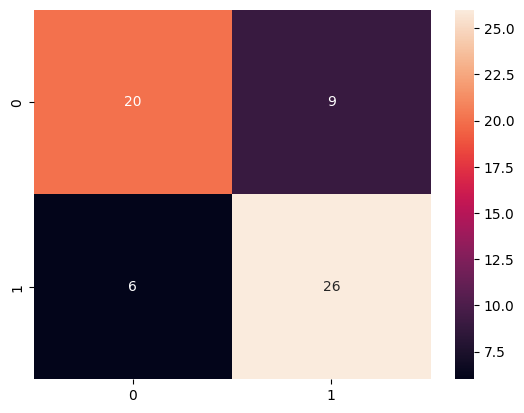

              precision    recall  f1-score   support

           0       0.77      0.69      0.73        29
           1       0.74      0.81      0.78        32

    accuracy                           0.75        61
   macro avg       0.76      0.75      0.75        61
weighted avg       0.76      0.75      0.75        61



In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

data = pd.read_csv("heart.csv")

X = data.drop("target", axis=1)
y = data["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scores = []

for k in range(1,20):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train,y_train)
    scores.append(knn.score(X_test,y_test))

best_k = scores.index(max(scores))+1

print("Best K:",best_k)

knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train,y_train)

y_pred = knn.predict(X_test)

print("Accuracy:",accuracy_score(y_test,y_pred))

cm = confusion_matrix(y_test,y_pred)

sns.heatmap(cm,annot=True)
plt.show()

print(classification_report(y_test,y_pred))